In [1]:
import pandas as pd

In [2]:
import pandas as pd
print(pd.__version__)

2.2.3


In [3]:
import os
print(os.getcwd())

C:\Artificial Itelligent\project\car price prdiction


In [4]:
!pip install pandas

In [5]:
data = pd.read_csv("car_price_dataset.csv")
print(data.head())
print(data.columns)

        Brand   Model  Year  Engine_Size Fuel_Type    Transmission  Mileage  \
0         Kia     Rio  2020          4.2    Diesel          Manual   289944   
1   Chevrolet  Malibu  2012          2.0    Hybrid       Automatic     5356   
2    Mercedes     GLA  2020          4.2    Diesel       Automatic   231440   
3        Audi      Q5  2023          2.0  Electric          Manual   160971   
4  Volkswagen    Golf  2003          2.6    Hybrid  Semi-Automatic   286618   

   Doors  Owner_Count  Price  
0      3            5   8501  
1      2            3  12092  
2      4            2  11171  
3      2            1  11780  
4      3            3   2867  
Index(['Brand', 'Model', 'Year', 'Engine_Size', 'Fuel_Type', 'Transmission',
       'Mileage', 'Doors', 'Owner_Count', 'Price'],
      dtype='object')


In [6]:
# Load the dataset
data = pd.read_csv("car_price_dataset.csv")

In [7]:
# Remove extra spaces from column names
data.columns = data.columns.str.strip()

In [8]:
# Check the column names
print(data.columns)

Index(['Brand', 'Model', 'Year', 'Engine_Size', 'Fuel_Type', 'Transmission',
       'Mileage', 'Doors', 'Owner_Count', 'Price'],
      dtype='object')


In [9]:
# Set the target column
TARGET_COLUMN = "Price"   # Use the exact column name

In [10]:
# Create features (X) and target (y)
X = data.drop(columns=[TARGET_COLUMN])
y = data[TARGET_COLUMN]
print(X.head())
print(y.head())

        Brand   Model  Year  Engine_Size Fuel_Type    Transmission  Mileage  \
0         Kia     Rio  2020          4.2    Diesel          Manual   289944   
1   Chevrolet  Malibu  2012          2.0    Hybrid       Automatic     5356   
2    Mercedes     GLA  2020          4.2    Diesel       Automatic   231440   
3        Audi      Q5  2023          2.0  Electric          Manual   160971   
4  Volkswagen    Golf  2003          2.6    Hybrid  Semi-Automatic   286618   

   Doors  Owner_Count  
0      3            5  
1      2            3  
2      4            2  
3      2            1  
4      3            3  
0     8501
1    12092
2    11171
3    11780
4     2867
Name: Price, dtype: int64


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

In [12]:
data = pd.read_csv("car_price_dataset.csv")

print("Dataset Shape:", data.shape)
print("\nColumns:\n", data.columns)

Dataset Shape: (10000, 10)

Columns:
 Index(['Brand', 'Model', 'Year', 'Engine_Size', 'Fuel_Type', 'Transmission',
       'Mileage', 'Doors', 'Owner_Count', 'Price'],
      dtype='object')


In [13]:
print(data.columns.tolist())

['Brand', 'Model', 'Year', 'Engine_Size', 'Fuel_Type', 'Transmission', 'Mileage', 'Doors', 'Owner_Count', 'Price']


In [14]:
target_column="Price"

In [15]:
data.columns=data.columns.str.strip()

In [16]:
# 1. Clean column names (removes hidden leading/trailing spaces)
data.columns = data.columns.str.strip()

# 2. Define target column 
# IMPORTANT: Check the output from Step 1. If it's "Price", change this to "Price"
TARGET_COLUMN = "Price" 

# 3. Use a 'Safe Drop' to avoid errors if the cell is run twice
if TARGET_COLUMN in data.columns:
    X = data.drop(TARGET_COLUMN, axis=1)
    y = data[TARGET_COLUMN]
    print(f"Successfully split data. Target: {TARGET_COLUMN}")
else:
    print(f"Error: '{TARGET_COLUMN}' not found. Available columns are: {data.columns.tolist()}")

Successfully split data. Target: Price


In [17]:
X = data.drop(TARGET_COLUMN, axis=1)
y = data[TARGET_COLUMN]

In [18]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [20]:
label_encoder = LabelEncoder()

for column in data.columns:
    if data[column].dtype == 'object':
        data[column] = label_encoder.fit_transform(data[column])

In [21]:
TARGET_COLUMN = "price"   # Change to "Price" if needed

if TARGET_COLUMN not in data.columns:
    print("Check your target column name. Available columns:")
    print(data.columns)
    exit()


Check your target column name. Available columns:
Index(['Brand', 'Model', 'Year', 'Engine_Size', 'Fuel_Type', 'Transmission',
       'Mileage', 'Doors', 'Owner_Count', 'Price'],
      dtype='object')


In [22]:
TARGET_COLUMN = "Price"   # Use the exact column name

X = data.drop(columns=[TARGET_COLUMN])
y = data[TARGET_COLUMN]

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(8000, 9)
(2000, 9)


In [24]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Make both datasets have the same columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [25]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [26]:
y_pred = model.predict(X_test)

In [27]:
import sklearn
print(sklearn.__version__)

1.6.1


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 793.4771350301191
MSE : 818588.252890057
RMSE: 904.7586710775736
R2 Score: 0.9109049829961213


In [29]:
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

print(results.head(10))

      Actual Price  Predicted Price
6252          2000      3074.303247
4684         11164     10645.029502
1731         14630     14097.481099
4742          7334      8738.732131
4521         10127     10508.083613
6340          7195      6524.225304
576           8292      6821.757048
5202          6229      6601.212449
6363          5776      5125.975149
439           4979      4430.930980


In [30]:
!pip install matplotlib

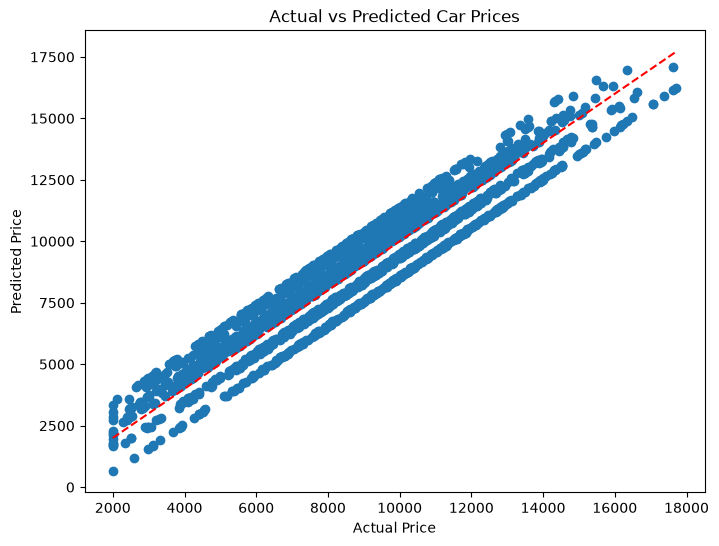

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')
plt.show()